In [11]:

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_curve, roc_auc_score
)

In [12]:
# Set Visualization Style
sns.set(style="whitegrid")

# ==========================================
# Load Dataset
# ==========================================

df1=pd.read_csv("diabetes.csv")
df2=pd.read_csv('indian_diabetes_synthetic_100k.csv')
data = df1+df2
print("First Five Rows of Dataset:")
print(data.head())

First Five Rows of Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          7.0    315.0          154.0           82.0     95.0  59.8   
1          4.0    190.0          149.0           67.0     71.0  46.3   
2         13.0    276.0          148.0           21.0      9.0  48.7   
3          1.0    161.0          147.0           41.0    186.0  60.0   
4          2.0    222.0          121.0           66.0    213.0  69.7   

   DiabetesPedigreeFunction   Age  Outcome  
0                     1.381  88.0      2.0  
1                     0.764  63.0      0.0  
2                     0.782  64.0      1.0  
3                     0.530  53.0      0.0  
4                     2.501  86.0      1.0  


In [13]:
# ==========================================
# Data Preprocessing
# ==========================================
# Replace invalid zeros with median values
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    data[col] = data[col].replace(0, np.nan)
    data[col].fillna(data[col].median(), inplace=True)

/var/folders/4k/lw9wr0jx5ms1xxpgzn3x_nkc0000gn/T/ipykernel_9057/3654384107.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


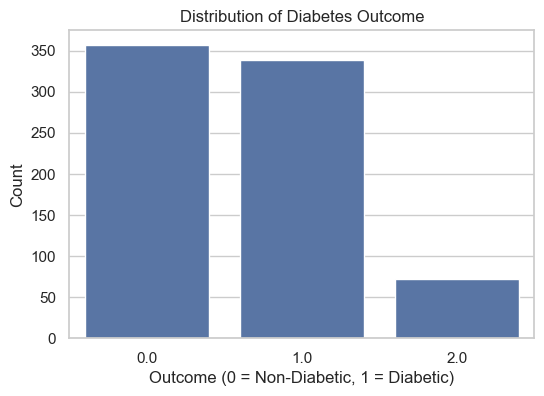

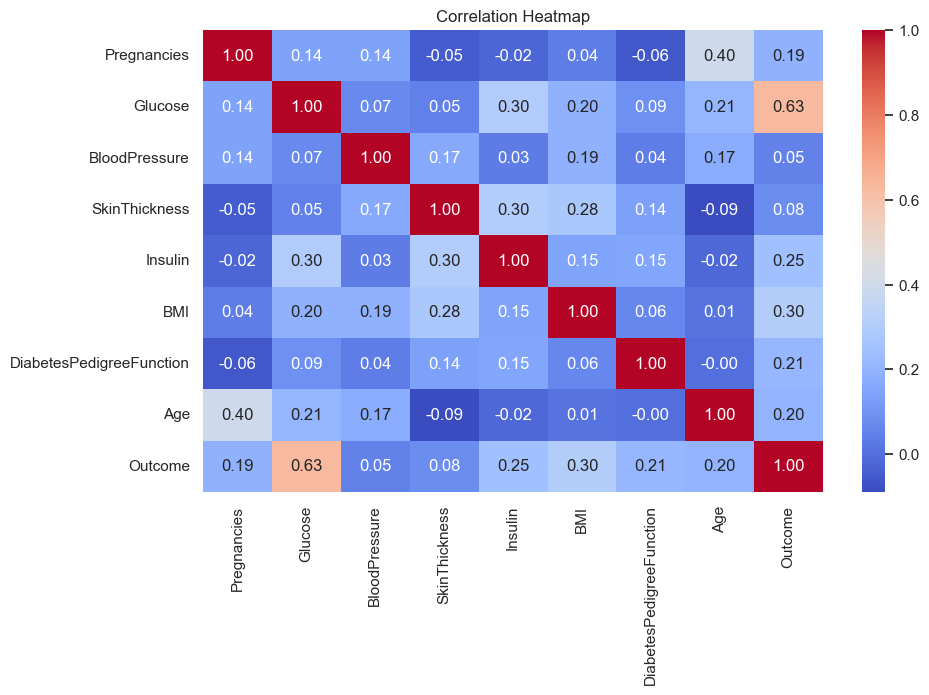

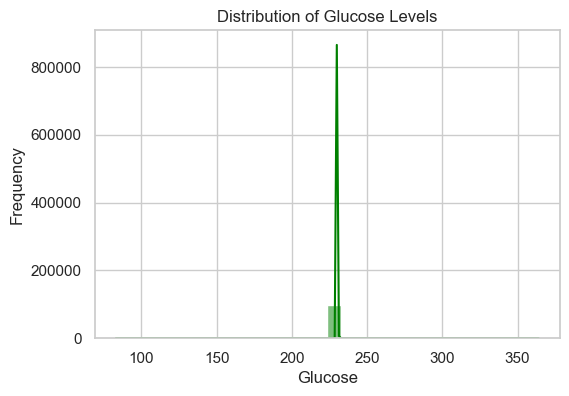

In [25]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

# Outcome Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data)
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Glucose Distribution
plt.figure(figsize=(6, 4))
sns.histplot(data['Glucose'], kde=True, bins=30, color='green')
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

In [38]:
# ==========================================
# Clean Target + Fix NaN + Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Keep only valid target classes
data = data[data['Outcome'].isin([0, 1])]

# Convert target column to integer
data['Outcome'] = data['Outcome'].astype(int)

# Remove missing target values
data = data.dropna(subset=['Outcome'])

# Feature and Target Separation
X = data.drop("Outcome", axis=1)

y = data["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (556, 8)
Test Shape: (140, 8)


In [39]:
# ==========================================
# Hyperparameter Tuning using GridSearchCV
# ==========================================
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [40]:
# ==========================================
# Model Prediction and Evaluation
# ==========================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Accuracy and Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n===== Model Performance =====")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


===== Model Performance =====
Accuracy Score: 0.7286
ROC-AUC Score: 0.7763

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        72
           1       0.73      0.69      0.71        68

    accuracy                           0.73       140
   macro avg       0.73      0.73      0.73       140
weighted avg       0.73      0.73      0.73       140



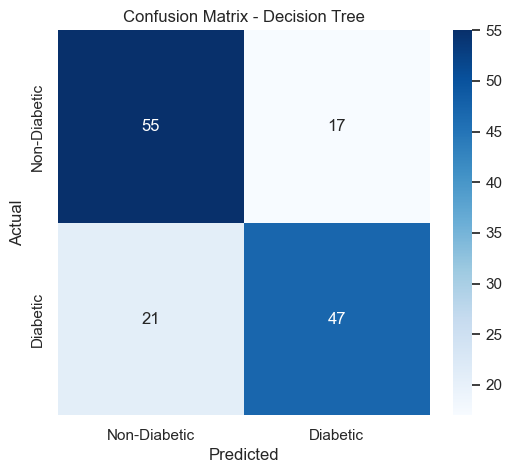

In [41]:
# ==========================================
# Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


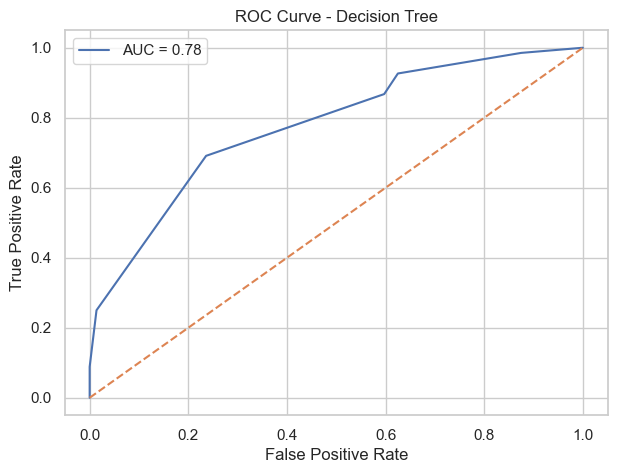

In [42]:
# ==========================================
# ROC Curve
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

/var/folders/4k/lw9wr0jx5ms1xxpgzn3x_nkc0000gn/T/ipykernel_9057/3317543204.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")


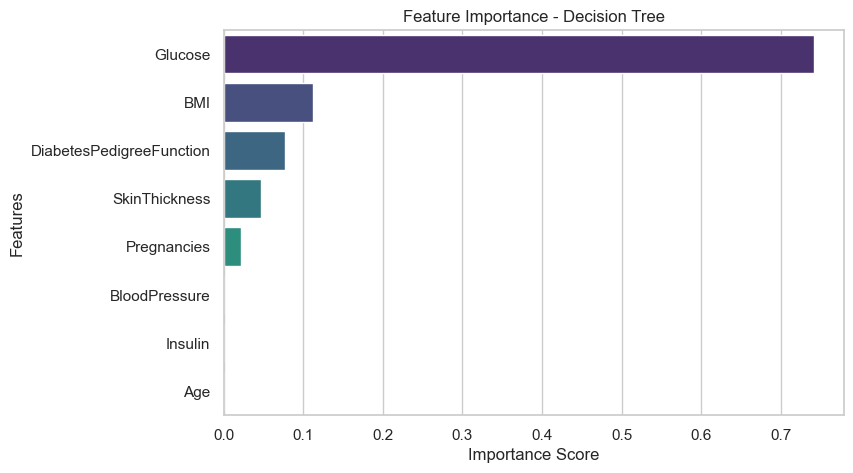

In [43]:
# ==========================================
# Feature Importance Plot
# ==========================================
feature_importances = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


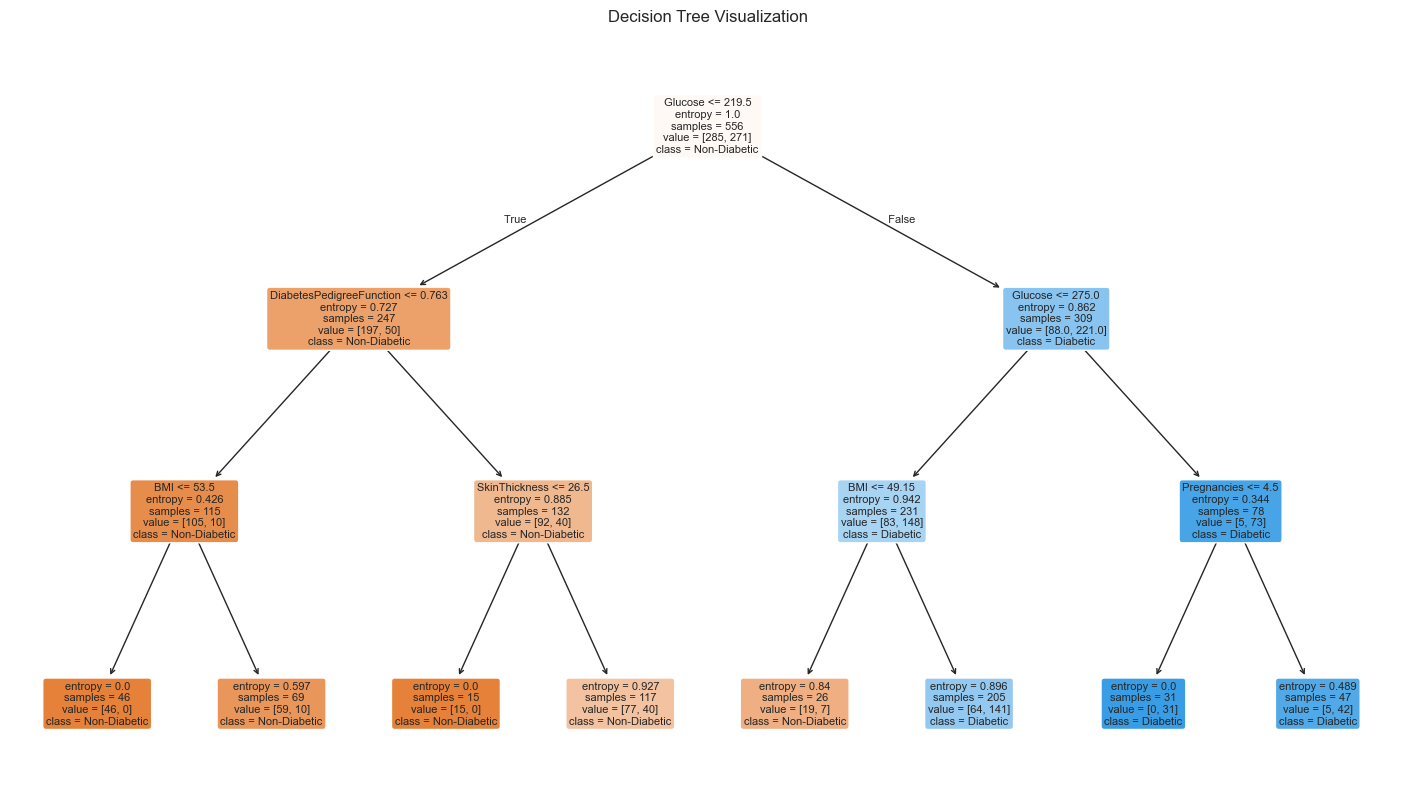

In [44]:
# ==========================================
# Decision Tree Visualization
# ==========================================
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()